# ADIM 4 — RQ2: SHAP açıklanabilirlik + setler-arası sürücü tutarlılığı

Açıklanan model: **HAM / doğal-dağılım LightGBM** (dengeleme YOK, kalibrasyon YOK) —
kâr zincirinin kullanacağı model. Adım 2 `best_params_<set>` ile TÜM veride fit
(seed=42). Açıklayıcı: `shap.TreeExplainer` (exact TreeSHAP).

5 **etiketli** set **bağımsız**; asla birleştirilmez. Asıl katkı: aynı **kavramların**
(tenure, sözleşme, kullanım, düşüş, şikâyet/destek, parasal, ödeme, hizmet, demografi)
farklı sektörlerde de güçlü churn sürücüsü olup olmadığını **kavram düzeyinde** karşılaştırmak
(veri birleştirilmeden, `src/concept_map.py` haritasıyla). Ağır mantık `src/`'de.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml bulunamadı")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from src import concept_map as km
from src import config as cfg
from src import plotstyle as ps
from src import shap_analysis as sa
from src import strings_tr as S

np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. Veri yükleme

In [2]:
veriler = {k: pd.read_csv(cfg.PROCESSED / f"{k}_clean.csv") for k in cfg.DATASETS}
for k, d in veriler.items():
    yaz(f"{k:11s} {d.shape}")

telco       (7043, 20)
cell2cell   (51047, 57)
ecommerce   (3941, 11)
iranian     (3150, 14)
bank        (10000, 11)


## 2. Her set için SHAP: global önem, beeswarm, dependence, tekil (waterfall)
cell2cell büyük olduğundan açıklama için stratified örneklem (n≤15000) kullanılır.

===== SHAP HESABI =====


telco: SHAP hesaplandı (örneklem n=7043); top sürücü: ['Contract', 'tenure', 'MonthlyCharges', 'OnlineSecurity', 'InternetService']
  (3s) olasılık: yüksek=0.908 düşük=0.011


cell2cell: SHAP açıklaması için stratified örneklem n=15000 (tam veri 51047).
cell2cell: SHAP hesaplandı (örneklem n=15000); top sürücü: ['CurrentEquipmentDays', 'MonthlyMinutes', 'MonthsInService', 'PercChangeMinutes', 'CreditRating']
  (9s) olasılık: yüksek=0.816 düşük=0.048


ecommerce: SHAP hesaplandı (örneklem n=3941); top sürücü: ['Tenure', 'Complain', 'CashbackAmount', 'NumberOfAddress', 'MaritalStatus']
  (6s) olasılık: yüksek=1.000 düşük=0.000


iranian: SHAP hesaplandı (örneklem n=3150); top sürücü: ['Status', 'Frequency of use', 'Complains', 'Seconds of Use', 'Call  Failure']
  (5s) olasılık: yüksek=1.000 düşük=0.000


bank: SHAP hesaplandı (örneklem n=10000); top sürücü: ['Age', 'NumOfProducts', 'IsActiveMember', 'Balance', 'Geography']
  (3s) olasılık: yüksek=0.947 düşük=0.019


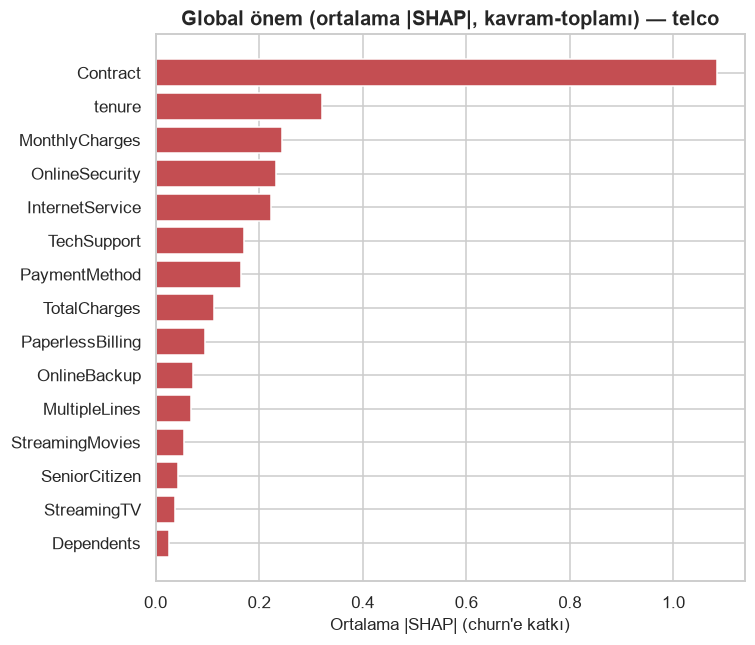

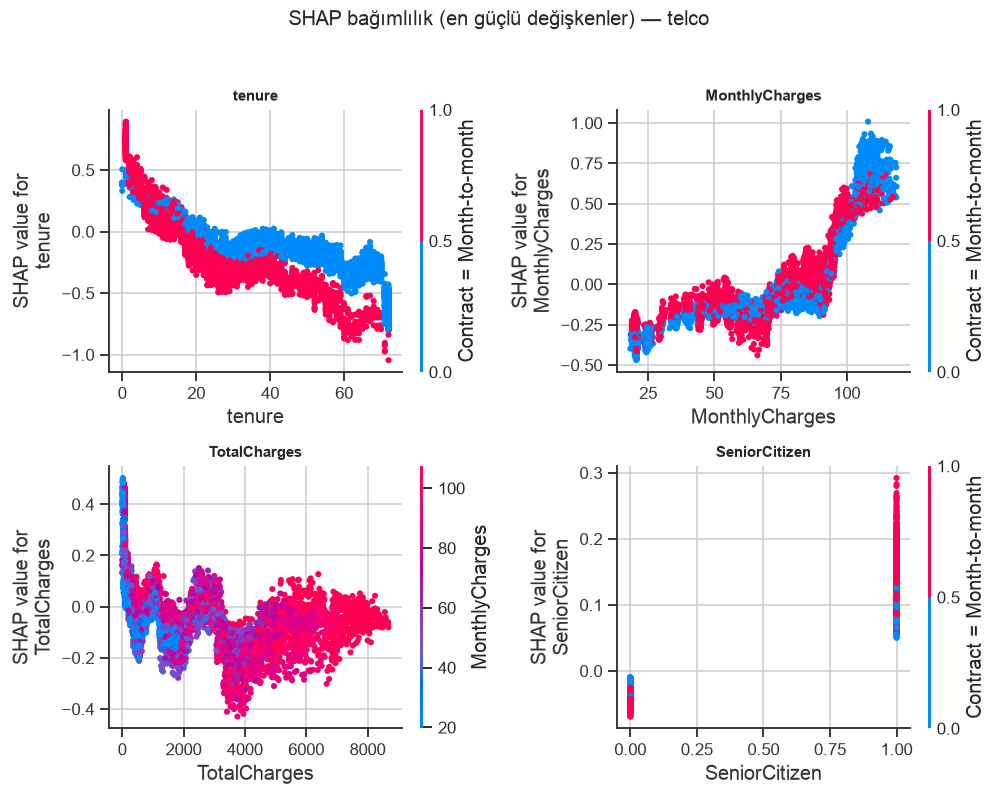

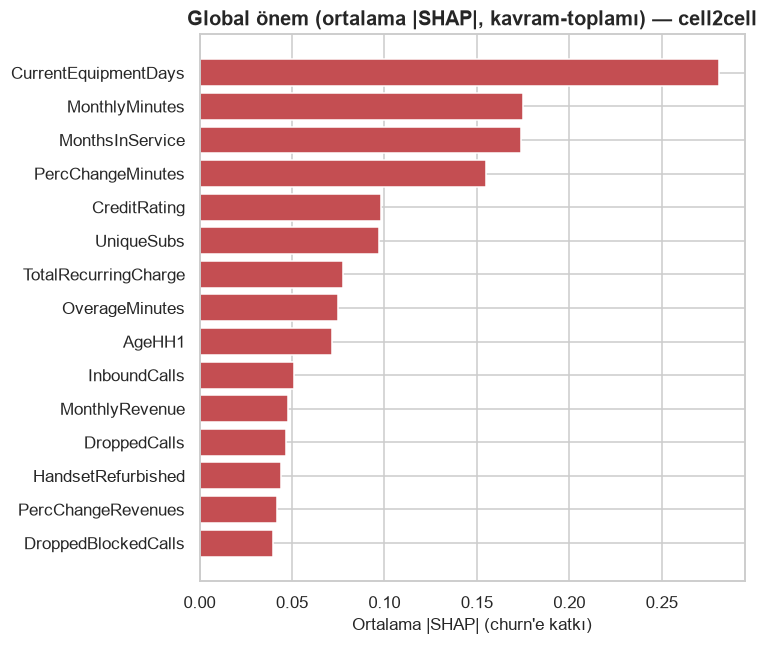

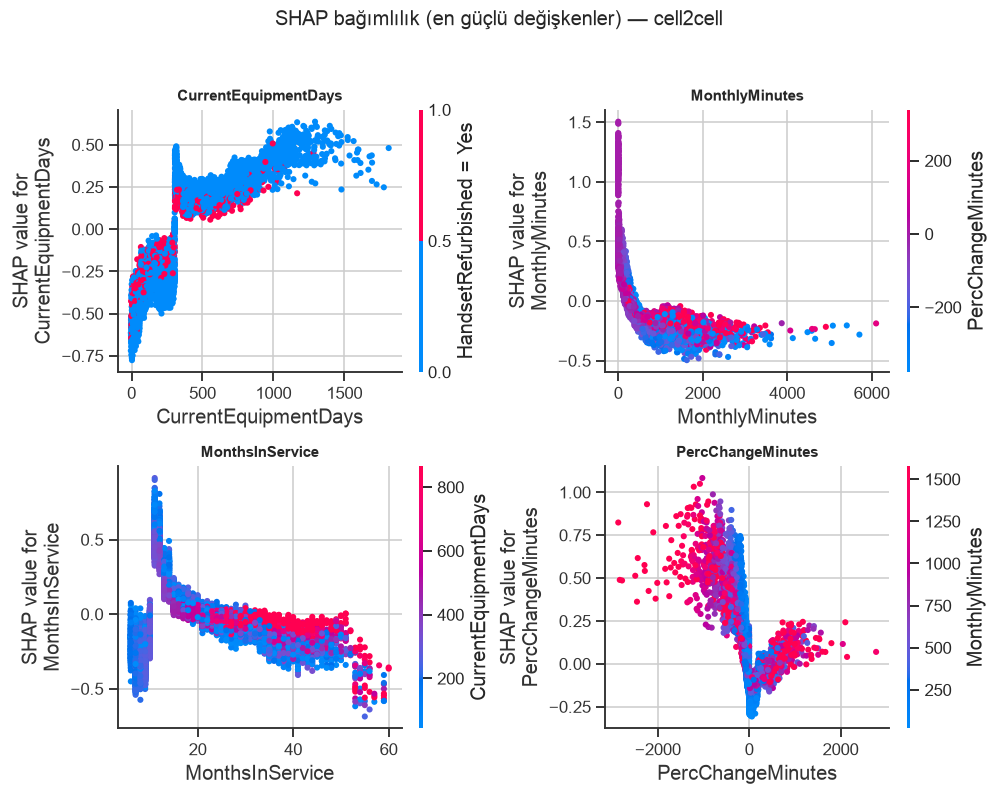

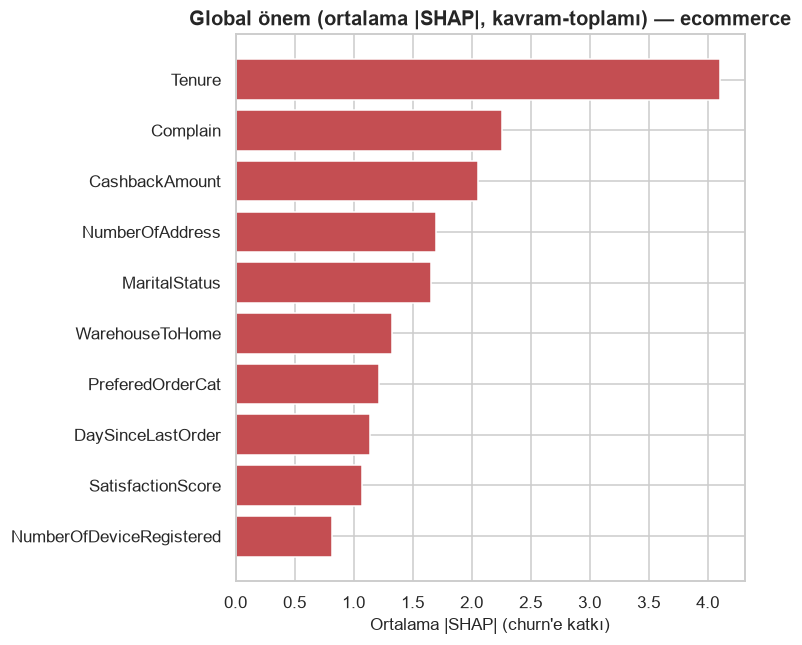

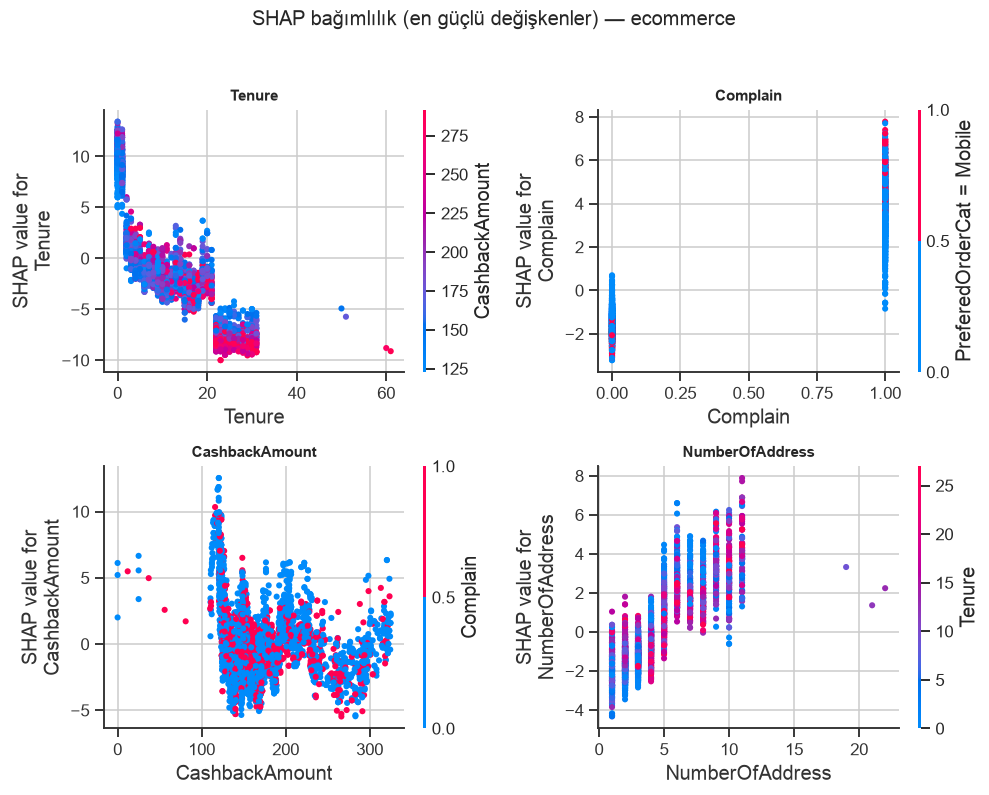

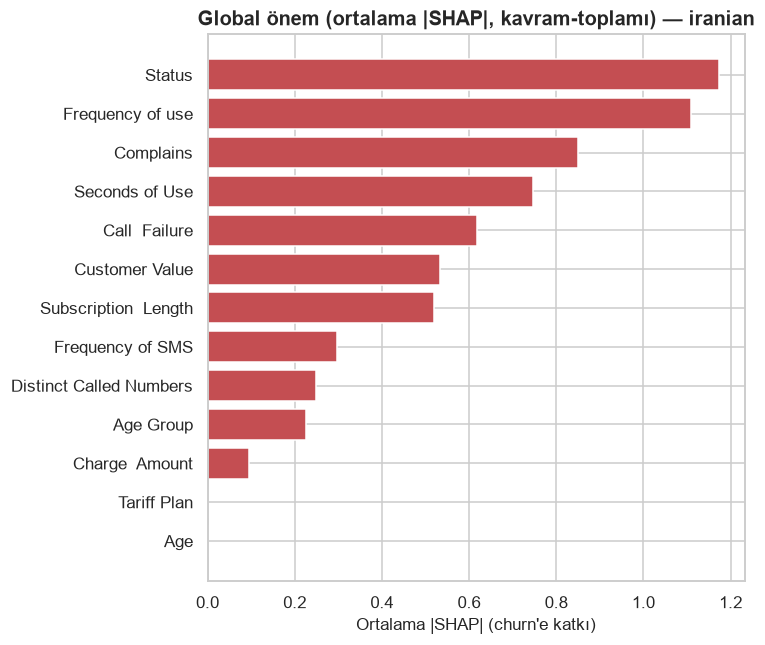

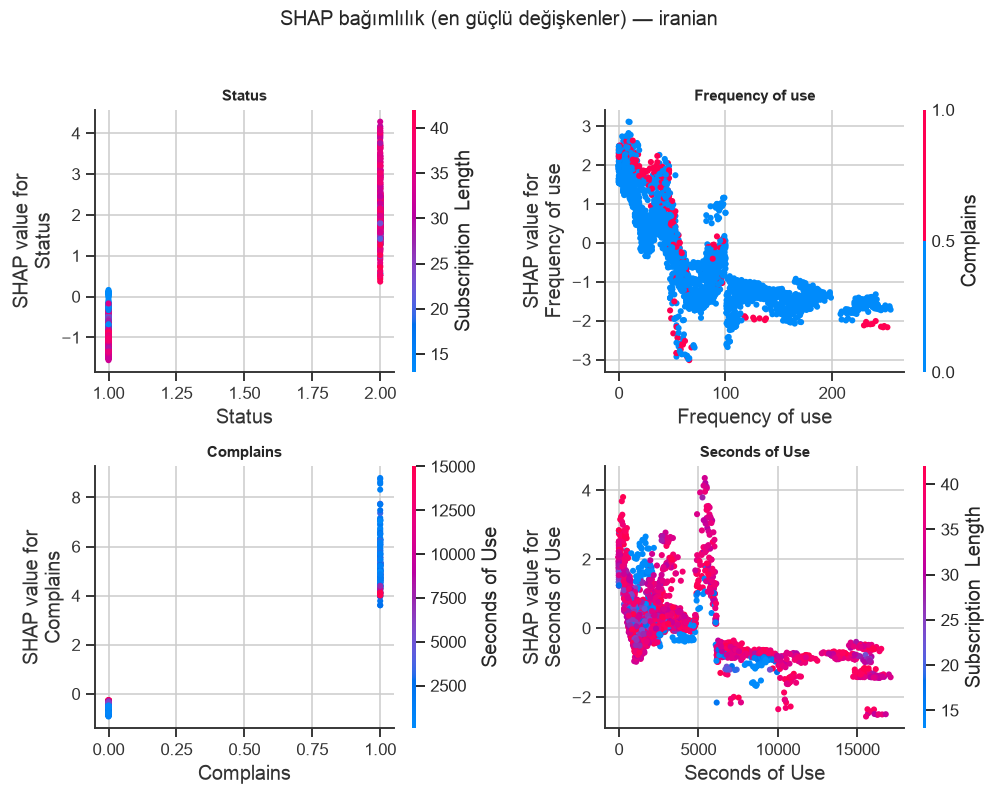

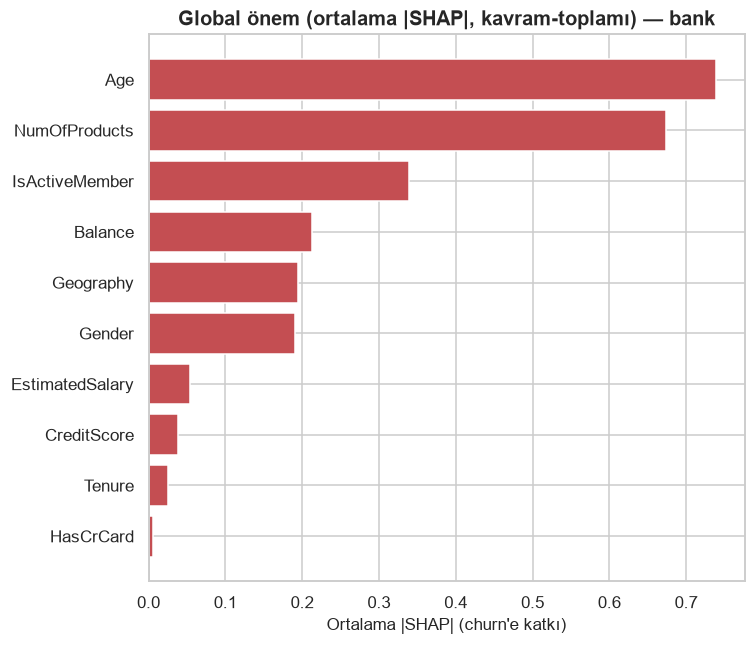

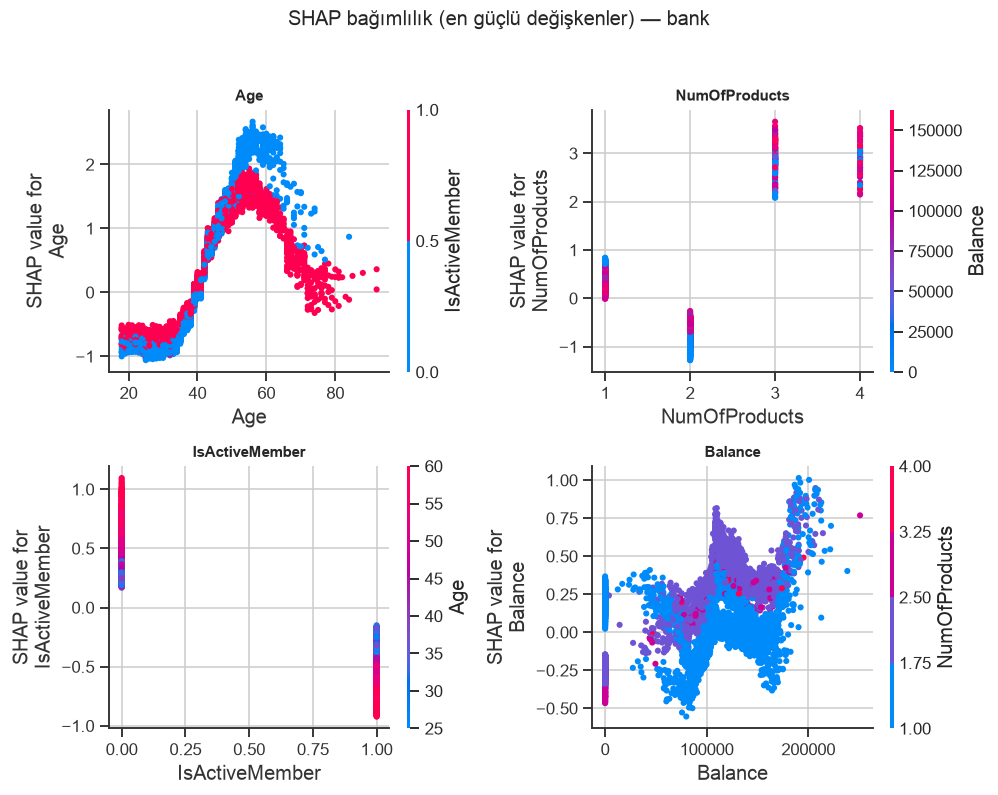

In [3]:
yaz(S.MSG["bolum"].format(ad="SHAP HESABI"))
tum_onem = {}
tum_local = {}
for k in cfg.DATASETS:
    t = time.time()
    h = sa.hazirla(k, veriler[k], cfg.SEED)
    sv, evb = sa.shap_hesap(h)
    onem = sa.onem_orijinal(sv, h["orijinaller"])
    tum_onem[k] = onem
    sa.tablo_global(k, onem)
    # eşlenemeyen (haritada olmayan) feature'lar
    eslenemeyen = [f for f in onem.index if f not in km.HARITA]
    if eslenemeyen:
        yaz(S.MSG4["eslenemeyen"].format(set=k, liste=eslenemeyen))
    # global figürler
    sa.figur_beeswarm(k, sv, h)
    sa.figur_importance(k, onem)
    sa.figur_dependence(k, sv, h, onem)
    # tekil: en yüksek / en düşük olasılıklı müşteri
    hi = int(np.argmax(h["proba"]))
    lo = int(np.argmin(h["proba"]))
    sa.figur_waterfall(k, sv, evb, h, hi, "high")
    sa.figur_waterfall(k, sv, evb, h, lo, "low")
    lokal = sa.tablo_local(k, sv, h, hi, lo)
    tum_local[k] = {"hi_p": float(h["proba"][hi]), "lo_p": float(h["proba"][lo])}
    if h["N"] > h["n_ornek"]:
        yaz(S.MSG4["ornek_not"].format(set=k, n=h["n_ornek"], N=h["N"]))
    yaz(S.MSG4["set"].format(set=k, n=h["n_ornek"], top=list(onem.head(5).index)))
    yaz(f"  ({time.time()-t:.0f}s) olasılık: yüksek={h['proba'][hi]:.3f} düşük={h['proba'][lo]:.3f}")

## 3. iranian 'Status' SHAP takibi
Status normal bir prediktör gibi mi davranıyor, yoksa tek başına her şeyi ezen baskınlık mı?

In [4]:
onem_ir = tum_onem["iranian"]
sira = list(onem_ir.index).index("Status") + 1
pay = 100 * onem_ir["Status"] / onem_ir.sum()
yorum = "tek baskın değil, diğer kullanım sürücüleriyle birlikte" if pay < 40 else "baskınlık şüphesi"
yaz(S.MSG["bolum"].format(ad="iranian 'Status' SHAP"))
yaz(S.MSG4["iranian_status"].format(sira=sira, toplam=len(onem_ir), pay=pay, yorum=yorum))

===== iranian 'Status' SHAP =====
iranian SHAP: 'Status' global önem sırası=1/13, pay=%18.3 — tek baskın değil, diğer kullanım sürücüleriyle birlikte


## 4. Setler-arası kavramsal sürücü tutarlılığı (ASIL KATKI)
Her setin sürücü önemleri kavramlara toplanır (pay), kavram × set ısı haritası.

In [5]:
matris, paylar = sa.tutarlilik(tum_onem)
yol_heat = sa.figur_tutarlilik(matris, list(cfg.DATASETS.keys()))
yaz(S.MSG["bolum"].format(ad="KAVRAMSAL TUTARLILIK (kavram payı, set bazında)"))
yaz(matris.to_string(index=False))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "rq2_driver_consistency.csv"))
yaz(S.MSG["kayit"].format(yol=yol_heat))

===== KAVRAMSAL TUTARLILIK (kavram payı, set bazında) =====
                            Kavram  telco  cell2cell  ecommerce  iranian   bank  Top-3 sektör sayısı
            İlişki süresi (tenure) 0.1062     0.0904     0.2368   0.0810 0.0104                    1
                Sözleşme / taahhüt 0.3580     0.0000     0.0000   0.0000 0.0000                    1
                    Kullanım hacmi 0.0000     0.2148     0.0471   0.5570 0.1372                    3
                   Kullanım düşüşü 0.0000     0.0978     0.0658   0.0000 0.0000                    0
Şikâyet / destek / hizmet kalitesi 0.0566     0.0931     0.1920   0.2287 0.0000                    2
           Parasal değer / harcama 0.1178     0.0626     0.1187   0.0980 0.1078                    2
               Ödeme / fatura tipi 0.0862     0.0018     0.0000   0.0000 0.0022                    0
         Hizmet / abonelik kapsamı 0.2418     0.0592     0.0000   0.0000 0.2720                    2
                         Demogr

## 5. Özet
Her set top-5 sürücü; tutarlı vs sektöre-özgü kavramlar. Yorum/karar kullanıcıda.

In [6]:
yaz(S.MSG["bolum"].format(ad="ÖZET"))
for k in cfg.DATASETS:
    yaz(f"{k:11s} top-5: {list(tum_onem[k].head(5).index)}")
tutarli = matris[matris[S.KOLON4["top3_say"]] >= 3][S.KOLON4["kavram"]].tolist()
ozgu = matris[matris[S.KOLON4["top3_say"]] == 1][S.KOLON4["kavram"]].tolist()
yaz(f"\nTUTARLI (≥3 sektörde top-3): {tutarli}")
yaz(f"SEKTÖRE ÖZGÜ (yalnız 1 sektörde top-3): {ozgu}")
yaz("")
yaz(S.MSG4["bitti"])

_log = cfg.LOGS / "adim4_ozet.log"
_log.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== ÖZET =====
telco       top-5: ['Contract', 'tenure', 'MonthlyCharges', 'OnlineSecurity', 'InternetService']
cell2cell   top-5: ['CurrentEquipmentDays', 'MonthlyMinutes', 'MonthsInService', 'PercChangeMinutes', 'CreditRating']
ecommerce   top-5: ['Tenure', 'Complain', 'CashbackAmount', 'NumberOfAddress', 'MaritalStatus']
iranian     top-5: ['Status', 'Frequency of use', 'Complains', 'Seconds of Use', 'Call  Failure']
bank        top-5: ['Age', 'NumOfProducts', 'IsActiveMember', 'Balance', 'Geography']

TUTARLI (≥3 sektörde top-3): ['Kullanım hacmi']
SEKTÖRE ÖZGÜ (yalnız 1 sektörde top-3): ['İlişki süresi (tenure)', 'Sözleşme / taahhüt']

ADIM 4 (RQ2) tamamlandı. Yorum/karar kullanıcıya bırakıldı. Kâr/ROI (RQ3) yapılmadı.
Kaydedildi: /Users/emrahfidan/Desktop/churn-xai-profit/outputs/logs/adim4_ozet.log
